## Step 1 — تحميل البيانات + Scaling

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

In [2]:
X_train = pd.read_csv('../data/cluster/X_train_clustring.csv')
X_test  = pd.read_csv('../data/cluster/X_test_clustring.csv')
y_train = pd.read_csv('../data/cluster/y_train_clustring.csv')
y_test  = pd.read_csv('../data/cluster/y_test_clustring.csv')

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

X_train: (952, 38)
X_test:  (239, 38)


### ليش Scaling?
KMeans و DBSCAN يحسبون **المسافة** بين الموظفين.
بدون Scaling: عمود قيمه 0-7 يسيطر على عمود قيمه 0-1.
StandardScaler يخلي كل عمود: متوسط=0 وانحراف=1.

**fit على train فقط** — نفس منطق Target Encoding لتجنب Data Leakage.

In [3]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"قبل Scaling: mean={X_train.iloc[:,0].mean():.2f}, std={X_train.iloc[:,0].std():.2f}")
print(f"بعد Scaling: mean={X_train_scaled[:,0].mean():.2f}, std={X_train_scaled[:,0].std():.2f}")

قبل Scaling: mean=0.56, std=0.50
بعد Scaling: mean=0.00, std=1.00


---
## Step 2 — Dimensionality Reduction (PCA)

### ليش نقلل الأبعاد قبل الكلسترنق؟
عندنا **38 عمود**. في الأبعاد العالية (Curse of Dimensionality):
- المسافة بين كل النقاط تصير **متشابهة**
- KMeans ما يقدر يفرّق بين قريب وبعيد
- بعض الأعمدة noise تشوّش


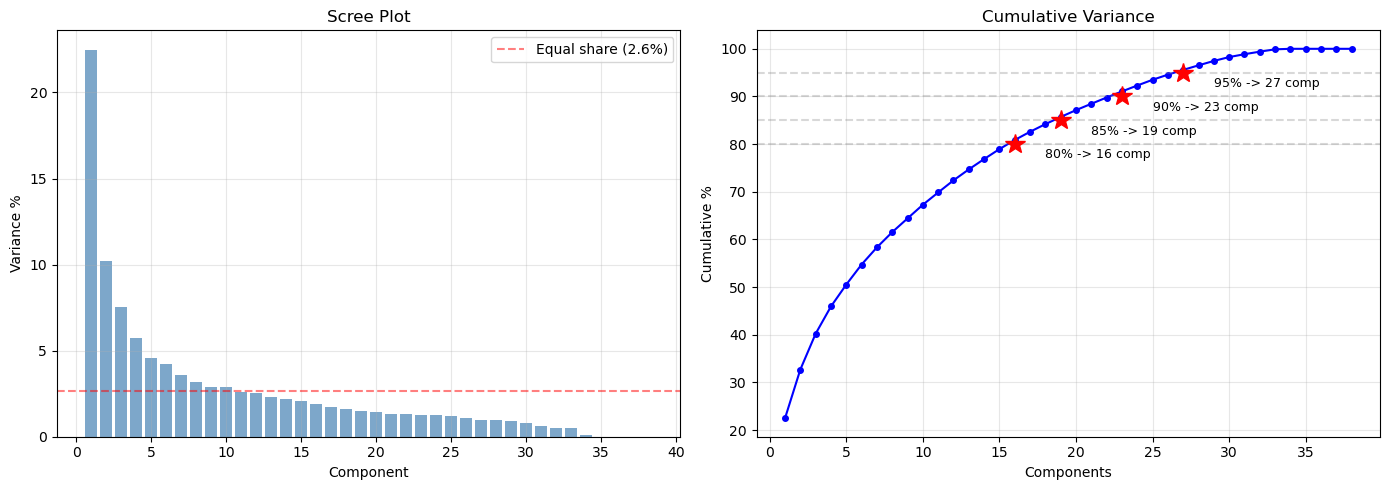

  80% -> 16 components (شلنا 22 عمود)
  85% -> 19 components (شلنا 19 عمود)
  90% -> 23 components (شلنا 15 عمود)
  95% -> 27 components (شلنا 11 عمود)


In [4]:
# كم Component نحتاج؟
pca_full = PCA(random_state=42)
pca_full.fit(X_train_scaled)
cumulative = np.cumsum(pca_full.explained_variance_ratio_) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(range(1, 39), pca_full.explained_variance_ratio_ * 100, color='steelblue', alpha=0.7)
ax1.axhline(y=100/38, color='r', linestyle='--', alpha=0.5, label=f'Equal share ({100/38:.1f}%)')
ax1.set_xlabel('Component'); ax1.set_ylabel('Variance %')
ax1.set_title('Scree Plot'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(range(1, 39), cumulative, 'bo-', markersize=4)
for t in [80, 85, 90, 95]:
    n = np.argmax(cumulative >= t) + 1
    ax2.axhline(y=t, color='gray', linestyle='--', alpha=0.3)
    ax2.plot(n, t, 'r*', markersize=15)
    ax2.annotate(f'{t}% -> {n} comp', xy=(n, t), xytext=(n+2, t-3), fontsize=9)
ax2.set_xlabel('Components'); ax2.set_ylabel('Cumulative %')
ax2.set_title('Cumulative Variance'); ax2.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

for t in [80, 85, 90, 95]:
    n = np.argmax(cumulative >= t) + 1
    print(f"  {t}% -> {n} components (شلنا {38-n} عمود)")

In [5]:
# أي Threshold الأفضل؟
print(f"{'Threshold':>10} {'Components':>10} {'Silhouette':>10}")
print("-" * 35)

sil_base = silhouette_score(X_train_scaled,
    KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10).fit_predict(X_train_scaled))
print(f"{'بدون PCA':>10} {38:>10} {sil_base:>10.3f}")

best_sil = sil_base; best_n = 38
for t in [80, 85, 90, 95]:
    n = np.argmax(cumulative >= t) + 1
    X_temp = PCA(n_components=n, random_state=42).fit_transform(X_train_scaled)
    sil = silhouette_score(X_temp,
        KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10).fit_predict(X_temp))
    mark = " <-- Best" if sil > best_sil else ""
    if sil > best_sil: best_sil = sil; best_n = n
    print(f"{f'{t}%':>10} {n:>10} {sil:>10.3f}{mark}")

print(f"\nالأفضل: {best_n} components")

 Threshold Components Silhouette
-----------------------------------
  بدون PCA         38      0.128
       80%         16      0.155 <-- Best
       85%         19      0.147
       90%         23      0.139
       95%         27      0.132

الأفضل: 16 components


In [6]:
# تطبيق PCA
pca_best = PCA(n_components=best_n, random_state=42)
X_train_pca = pca_best.fit_transform(X_train_scaled)
X_test_pca  = pca_best.transform(X_test_scaled)

print(f"قبل: {X_train_scaled.shape[1]} عمود")
print(f"بعد: {X_train_pca.shape[1]} component ({cumulative[best_n-1]:.0f}% variance)")

قبل: 38 عمود
بعد: 16 component (81% variance)


---
## Step 3 — Elbow + Silhouette

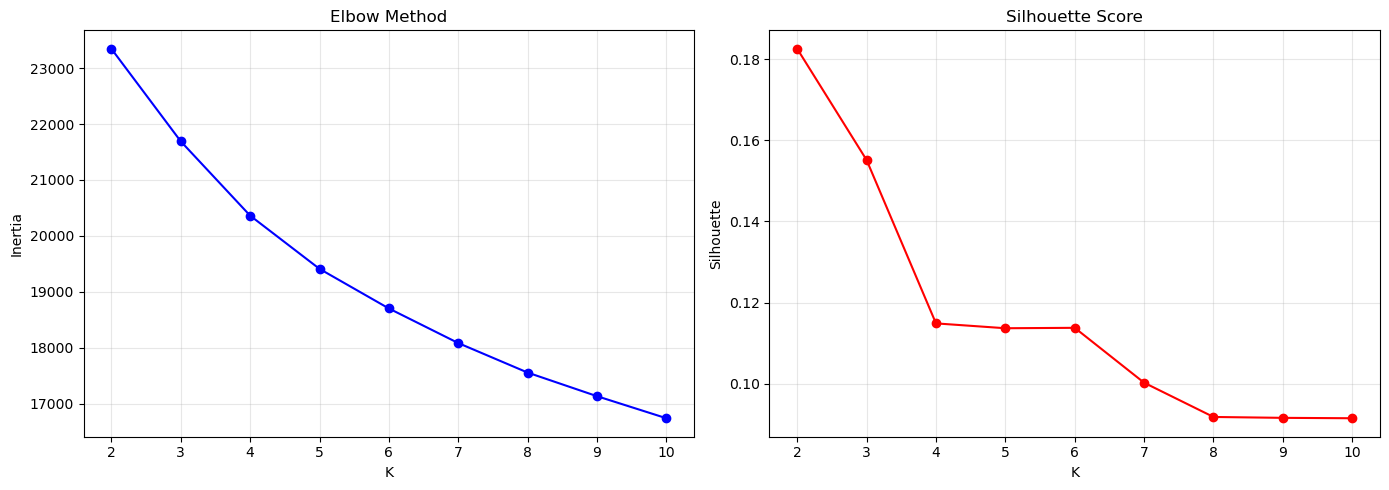

  K=2: 0.183
  K=3: 0.155
  K=4: 0.115
  K=5: 0.114
  K=6: 0.114
  K=7: 0.100
  K=8: 0.092
  K=9: 0.092
  K=10: 0.091


In [7]:
inertia = []; sil_scores = []; K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_train_pca)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_train_pca, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(K_range, inertia, 'bo-')
ax1.set_xlabel('K'); ax1.set_ylabel('Inertia'); ax1.set_title('Elbow Method')
ax1.set_xticks(K_range); ax1.grid(True, alpha=0.3)

ax2.plot(K_range, sil_scores, 'ro-')
ax2.set_xlabel('K'); ax2.set_ylabel('Silhouette'); ax2.set_title('Silhouette Score')
ax2.set_xticks(K_range); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

for k, s in zip(K_range, sil_scores):
    print(f"  K={k}: {s:.3f}")

---
## Step 4 — مقارنة الخوارزميات



In [8]:
# 4.1 KMeans (random)
km_random = KMeans(n_clusters=3, init='random', random_state=42, n_init=10)
labels_random = km_random.fit_predict(X_train_pca)
sil_random = silhouette_score(X_train_pca, labels_random)
print(f"KMeans (random):  Sil = {sil_random:.3f}  |  توزيع: {np.bincount(labels_random)}")

KMeans (random):  Sil = 0.155  |  توزيع: [363 436 153]


In [9]:
# 4.2 KMeans++
km_plus = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
labels_plus = km_plus.fit_predict(X_train_pca)
sil_plus = silhouette_score(X_train_pca, labels_plus)
print(f"KMeans++:         Sil = {sil_plus:.3f}  |  توزيع: {np.bincount(labels_plus)}")

KMeans++:         Sil = 0.155  |  توزيع: [153 363 436]


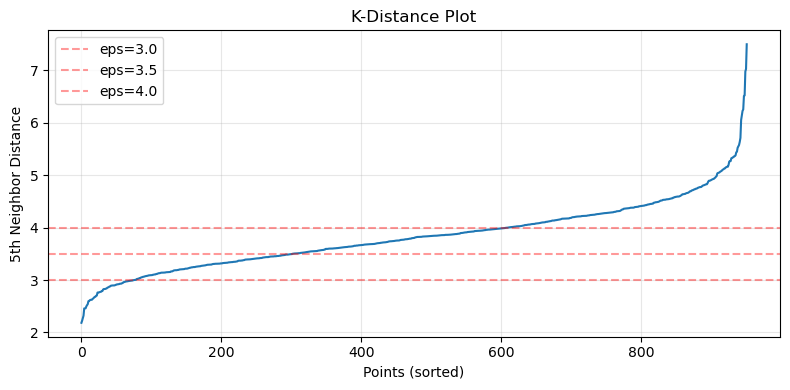

In [10]:
# 4.3 DBSCAN — K-Distance Plot
nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_train_pca)
distances, _ = nn.kneighbors(X_train_pca)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 4))
plt.plot(k_distances)
plt.xlabel('Points (sorted)'); plt.ylabel('5th Neighbor Distance')
plt.title('K-Distance Plot'); plt.grid(True, alpha=0.3)
for v in [3.0, 3.5, 4.0]:
    plt.axhline(y=v, color='r', linestyle='--', alpha=0.4, label=f'eps={v}')
plt.legend(); plt.tight_layout(); plt.show()

In [11]:
# تجربة قيم eps مختلفة
print(f"{'eps':>5} {'min_s':>5} {'clusters':>8} {'noise%':>7} {'silhouette':>10}")
print("-" * 40)

best_sil_db = -1; best_eps = None; best_min = None
for eps in [2.5, 3.0, 3.5, 4.0, 4.5, 5.0]:
    for min_s in [3, 5, 7, 10]:
        db_labels = DBSCAN(eps=eps, min_samples=min_s).fit_predict(X_train_pca)
        n_c = len(set(db_labels)) - (1 if -1 in db_labels else 0)
        n_noise = (db_labels == -1).sum()
        noise_pct = n_noise / len(db_labels) * 100
        sil = -1
        if n_c >= 2 and n_noise < len(db_labels) * 0.5:
            mask = db_labels != -1
            if len(set(db_labels[mask])) >= 2:
                sil = silhouette_score(X_train_pca[mask], db_labels[mask])
        if sil > best_sil_db:
            best_sil_db = sil; best_eps = eps; best_min = min_s
        sil_str = f"{sil:.3f}" if sil > 0 else "  N/A"
        print(f"{eps:5.1f} {min_s:5d} {n_c:8d} {noise_pct:6.1f}% {sil_str:>10}")

labels_dbscan = DBSCAN(eps=best_eps, min_samples=best_min).fit_predict(X_train_pca)
n_noise = (labels_dbscan == -1).sum()
n_clusters_db = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
print(f"\nBest DBSCAN: eps={best_eps}, min={best_min}, noise={n_noise} ({n_noise/len(labels_dbscan)*100:.1f}%)")

  eps min_s clusters  noise% silhouette
----------------------------------------
  2.5     3       13   93.4%        N/A
  2.5     5        3   98.0%        N/A
  2.5     7        0  100.0%        N/A
  2.5    10        0  100.0%        N/A
  3.0     3       23   67.4%        N/A
  3.0     5       11   80.5%        N/A
  3.0     7        8   89.5%        N/A
  3.0    10        3   95.3%        N/A
  3.5     3        8   36.4%        N/A
  3.5     5        6   45.4%        N/A
  3.5     7        2   53.4%        N/A
  3.5    10        5   65.3%        N/A
  4.0     3        2   12.4%      0.153
  4.0     5        2   15.2%      0.203
  4.0     7        2   18.4%        N/A
  4.0    10        1   23.9%        N/A
  4.5     3        1    3.7%        N/A
  4.5     5        1    4.3%        N/A
  4.5     7        1    4.7%        N/A
  4.5    10        1    6.1%        N/A
  5.0     3        1    1.3%        N/A
  5.0     5        1    1.3%        N/A
  5.0     7        1    1.5%        N/A

In [12]:
# جدول المقارنة
mask_db = labels_dbscan != -1
sil_db = silhouette_score(X_train_pca[mask_db], labels_dbscan[mask_db]) if mask_db.sum() > 0 and len(set(labels_dbscan[mask_db])) >= 2 else -1
sil_db_str = f"{sil_db:.3f}" if sil_db > 0 else "N/A"

print("=" * 55)
print(f"{'Algorithm':<18} {'Silhouette':>10} {'Clusters':>8} {'Noise':>8}")
print("=" * 55)
print(f"{'KMeans (random)':<18} {sil_random:>10.3f} {3:>8} {0:>8}")
print(f"{'KMeans++':<18} {sil_plus:>10.3f} {3:>8} {0:>8}")
print(f"{'DBSCAN':<18} {sil_db_str:>10} {n_clusters_db:>8} {n_noise:>8}")
print("=" * 55)

Algorithm          Silhouette Clusters    Noise
KMeans (random)         0.155        3        0
KMeans++                0.155        3        0
DBSCAN                  0.203        2      145


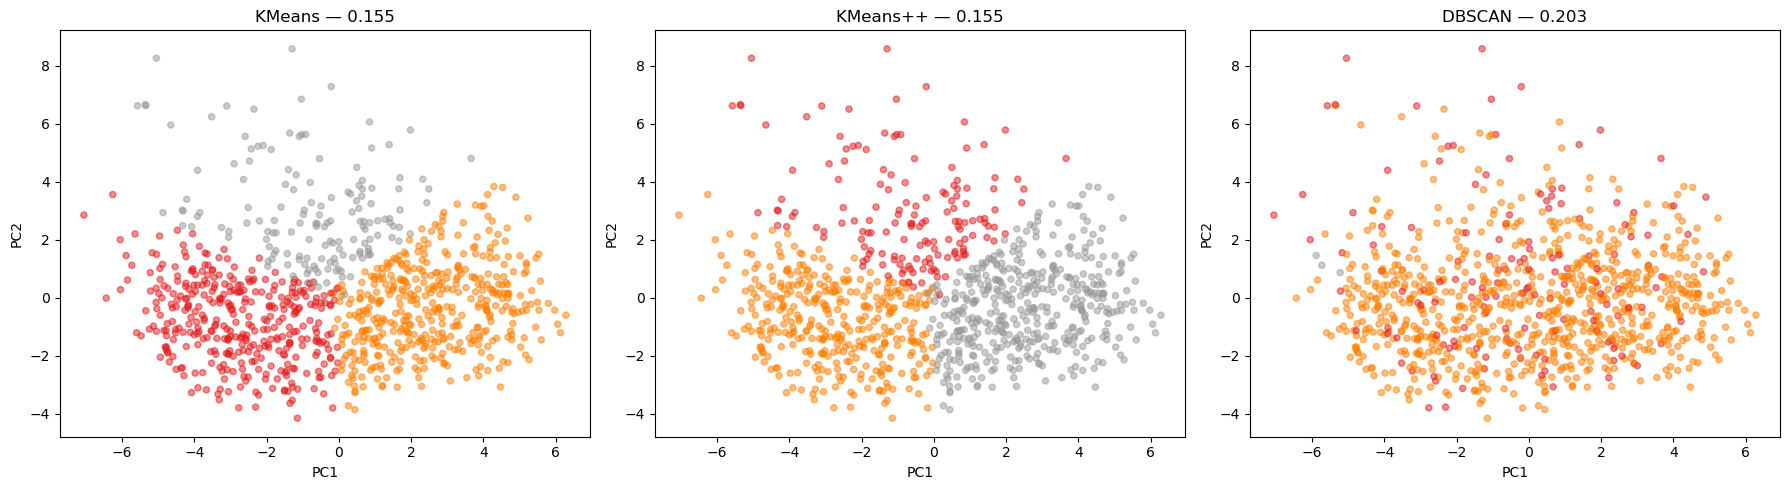

In [13]:
# مقارنة بصرية
X_2d = PCA(n_components=2, random_state=42).fit_transform(X_train_pca)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, lbl, name in [(axes[0], labels_random, f'KMeans — {sil_random:.3f}'),
                       (axes[1], labels_plus, f'KMeans++ — {sil_plus:.3f}'),
                       (axes[2], labels_dbscan, f'DBSCAN — {sil_db_str}')]:
    ax.scatter(X_2d[:, 0], X_2d[:, 1], c=lbl, cmap='Set1', alpha=0.5, s=20)
    ax.set_title(name); ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.tight_layout(); plt.show()

**النتيجة:** KMeans++ أفضل — DBSCAN فشل لأن البيانات فئوية متراكبة بدون كثافات منفصلة.

---
## Step 5 — مقارنة K=3 vs K=6

In [14]:
results = {}
y_vals = y_train.values.ravel()

for k in [3, 6]:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = km.fit_predict(X_train_pca)
    sil = silhouette_score(X_train_pca, labels)
    counts = np.bincount(labels)
    results[k] = {'labels': labels, 'sil': sil, 'counts': counts}
    
    print(f"\n{'='*55}")
    print(f"K={k}  |  Silhouette={sil:.3f}  |  Smallest={counts.min()} ({counts.min()/len(labels)*100:.1f}%)")
    print(f"{'='*55}")
    rates = []
    for c in range(k):
        mask = labels == c
        rate = y_vals[mask].mean() * 100
        rates.append(rate)
        print(f"  Cluster {c}: {rate:5.1f}% attrition ({mask.sum()} emp)")
    results[k]['spread'] = max(rates) - min(rates)
    print(f"  Spread: {max(rates)-min(rates):.1f} points")


K=3  |  Silhouette=0.155  |  Smallest=153 (16.1%)
  Cluster 0:  22.2% attrition (153 emp)
  Cluster 1:  35.3% attrition (363 emp)
  Cluster 2:  57.3% attrition (436 emp)
  Spread: 35.1 points

K=6  |  Silhouette=0.114  |  Smallest=48 (5.0%)
  Cluster 0:   2.1% attrition (48 emp)
  Cluster 1:  55.4% attrition (168 emp)
  Cluster 2:  25.7% attrition (253 emp)
  Cluster 3:  52.7% attrition (207 emp)
  Cluster 4:  74.3% attrition (136 emp)
  Cluster 5:  30.7% attrition (140 emp)
  Spread: 72.2 points


In [16]:
# هل كل كلستر مختلف فعلاً؟
scores = ['Burnout_Score', 'Stagnation_Score', 'Disengagement_Score', 'Compensation_Gap']
overall = X_train[scores].mean()

for k in [3, 6]:
    temp = X_train.copy()
    temp['_C'] = results[k]['labels']
    profiles = temp.groupby('_C')[scores].mean()
    deviation = (profiles - overall) / overall
    
    print(f"\n{'='*55}")
    print(f"K={k} — هوية كل كلستر:")
    identities = []
    for c in range(k):
        top_p = deviation.loc[c].idxmax(); val_p = deviation.loc[c].max()
        top_n = deviation.loc[c].idxmin(); val_n = deviation.loc[c].min()
        if abs(val_p) >= abs(val_n):
            nm = top_p.replace('_Score','').replace('_Gap','')
            identities.append(top_p)
            print(f"  C{c} ({results[k]['counts'][c]:3d}): أعلى {nm} (+{val_p:.0%})")
        else:
            nm = top_n.replace('_Score','').replace('_Gap','')
            identities.append('Low_' + top_n)
            print(f"  C{c} ({results[k]['counts'][c]:3d}): أقل {nm} ({val_n:.0%})")
    
    uniq = len(set(identities))
    if uniq < len(identities):
        print(f"  ⚠️ {len(identities)-uniq} تكرار!")
    else:
        print(f"  ✅ كل كلستر فريد")


K=3 — هوية كل كلستر:
  C0 (153): أعلى Stagnation (+42%)
  C1 (363): أقل Compensation (-38%)
  C2 (436): أعلى Burnout (+35%)
  ✅ كل كلستر فريد

K=6 — هوية كل كلستر:
  C0 ( 48): أعلى Stagnation (+102%)
  C1 (168): أقل Stagnation (-14%)
  C2 (253): أقل Burnout (-42%)
  C3 (207): أعلى Burnout (+58%)
  C4 (136): أعلى Stagnation (+11%)
  C5 (140): أقل Burnout (-9%)
  ⚠️ 2 تكرار!


---
## Step 6 — الكلسترنق النهائي (K=3, KMeans++)

In [17]:
kmeans_final = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
kmeans_final.fit(X_train_pca)

X_train['Cluster'] = kmeans_final.predict(X_train_pca)
X_test['Cluster']  = kmeans_final.predict(X_test_pca)

print("Train:"); print(X_train['Cluster'].value_counts().sort_index())
print(f"\nTest:"); print(X_test['Cluster'].value_counts().sort_index())

Train:
Cluster
0    153
1    363
2    436
Name: count, dtype: int64

Test:
Cluster
0     38
1     95
2    106
Name: count, dtype: int64


         Burnout_Score  Stagnation_Score  Disengagement_Score  \
Cluster                                                         
0                 2.87              3.63                 3.87   
1                 2.22              1.85                 3.43   
2                 4.59              2.77                 5.89   

         Compensation_Gap  
Cluster                    
0                    1.44  
1                    0.96  
2                    2.07  


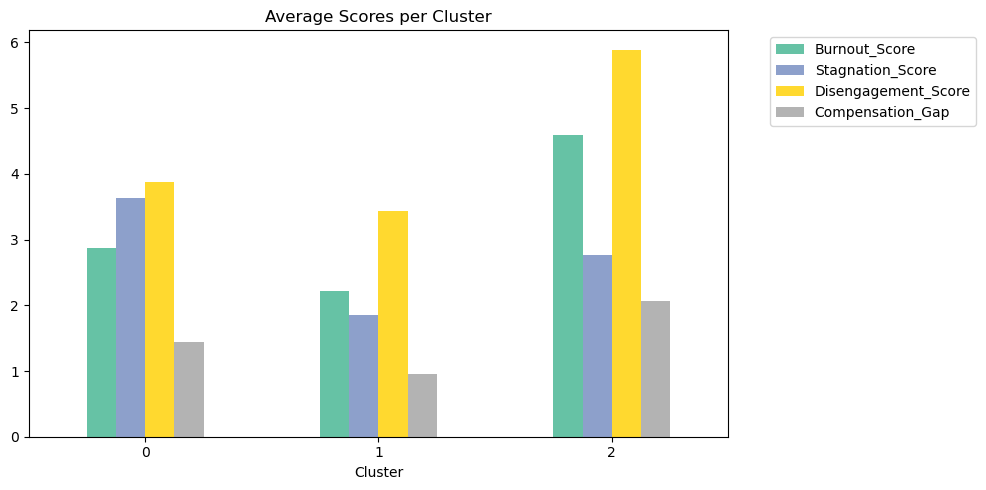

In [18]:
# متوسط المؤشرات
scores = ['Burnout_Score', 'Stagnation_Score', 'Disengagement_Score', 'Compensation_Gap']
profiles = X_train.groupby('Cluster')[scores].mean().round(2)
print(profiles)

profiles.plot(kind='bar', figsize=(10, 5), colormap='Set2')
plt.title('Average Scores per Cluster'); plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1)); plt.tight_layout(); plt.show()

In [19]:
# نسبة الاستقالة
print("نسبة الاستقالة:\n")
for c in sorted(X_train['Cluster'].unique()):
    mask = X_train['Cluster'] == c
    rate = y_train.values.ravel()[mask.values].mean() * 100
    print(f"  Cluster {c}: {rate:.1f}% ({mask.sum()} employees)")

نسبة الاستقالة:

  Cluster 0: 22.2% (153 employees)
  Cluster 1: 35.3% (363 employees)
  Cluster 2: 57.3% (436 employees)


### أكثر Features تأثيراً — كيف نقرأ النتائج؟

نقارن **متوسط كل عمود في الكلستر** بالمتوسط العام. مثال:

| النتيجة | المعنى |
|---|---|
| `Psychological_Exhaustion  أقل (فرق: 0.24)` | موظفين هالكلستر إرهاقهم النفسي **أقل من الباقي بـ 0.24** |
| `Distance_to_work  أقل (فرق: 0.23)` | موظفين هالكلستر **أقرب للعمل** من الباقي |
| `Emotional_Commitment  أعلى (فرق: 0.22)` | موظفين هالكلستر **ارتباطهم العاطفي أعلى** من الباقي |

**القاعدة:**
- **أعلى + فرق كبير** = هالشيء عالي عندهم — يميّزهم
- **أقل + فرق كبير** = هالشيء ناقص عندهم
- **فرق صغير (< 0.1)** = ما يفرق — ما يميّز الكلستر

In [22]:
# أكثر Features تأثيراً — مع القيم الفعلية للوضوح
overall_mean = X_train.drop(columns='Cluster').mean()
cluster_means = X_train.groupby('Cluster').mean()

print("=" * 85)
for cluster in sorted(X_train['Cluster'].unique()):
    diff = (cluster_means.loc[cluster] - overall_mean).abs().sort_values(ascending=False)
    print(f"\nCluster {cluster} — أكثر 10 Features اختلافاً:\n")
    print(f"  {'Feature':<40} {'اتجاه':>5} {'الكلستر':>8} {'المتوسط':>8} {'الفرق':>6}")
    print(f"  {'-'*70}")
    for feat, val in diff.items():
        actual = cluster_means.loc[cluster][feat]
        avg = overall_mean[feat]
        direction = "أعلى" if actual > avg else "أقل"
        print(f"  {feat:<40} {direction:>5} {actual:>8.2f} {avg:>8.2f} {val:>6.2f}")
    print("=" * 85)


Cluster 0 — أكثر 10 Features اختلافاً:

  Feature                                  اتجاه  الكلستر  المتوسط  الفرق
  ----------------------------------------------------------------------
  Stagnation_Score                          أعلى     3.63     2.56   1.08
  Years_experience_lastorganization         أعلى     2.61     1.58   1.03
  Years_Experience                          أعلى     2.83     1.85   0.98
  Disengagement_Score                        أقل     3.87     4.63   0.76
  Age                                       أعلى     2.26     1.64   0.63
  Allowances                                 أقل     0.63     1.21   0.58
  Burnout_Score                              أقل     2.87     3.41   0.54
  Payment_Overtime                           أقل     1.37     1.87   0.49
  MedicalInsurance                           أقل     0.37     0.70   0.33
  OverTime                                   أقل     0.12     0.43   0.31
  Maritalstatus_single                       أقل     0.10     0.40   0.3

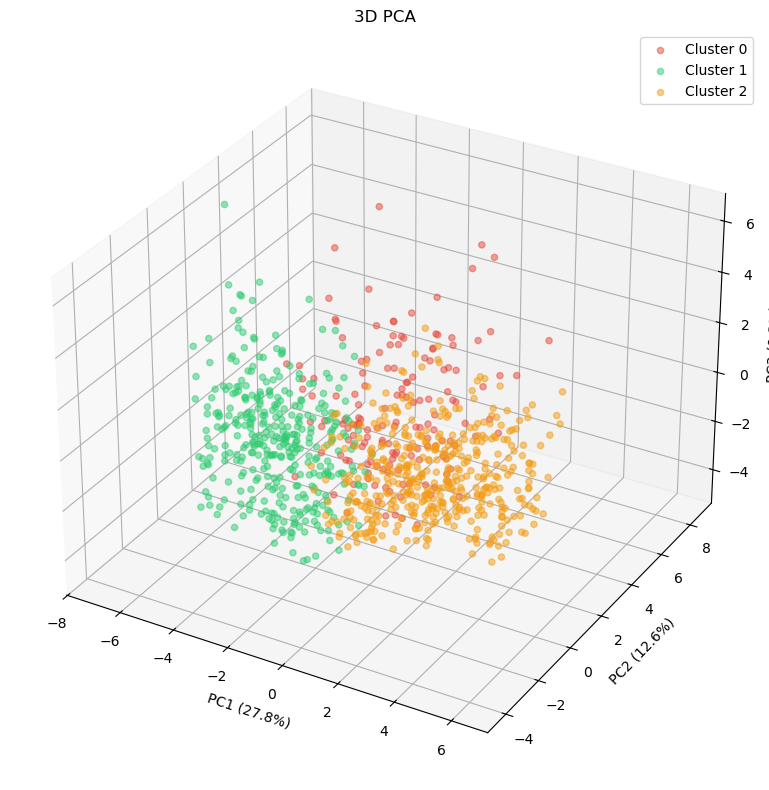

In [21]:
# 3D PCA
from mpl_toolkits.mplot3d import Axes3D
pca_3d = PCA(n_components=3, random_state=42)
X_3d = pca_3d.fit_transform(X_train_pca)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
colors = ['#E74C3C', '#2ECC71', '#F39C12']
for c in range(3):
    mask = X_train['Cluster'] == c
    ax.scatter(X_3d[mask, 0], X_3d[mask, 1], X_3d[mask, 2],
               c=colors[c], label=f'Cluster {c}', alpha=0.5, s=20)
ax.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]:.1%})')
ax.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]:.1%})')
ax.set_title('3D PCA'); ax.legend(); plt.tight_layout(); plt.show()

---
## Step 7 — الحفظ

In [23]:
X_train.to_csv('../data/X_train_clustered.csv', index=False)
X_test.to_csv('../data/X_test_clustered.csv', index=False)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print("\n Done")

X_train: (952, 39)
X_test:  (239, 39)

 Done


In [24]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

class FeatureEngineerHR(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.required_cols_ = [
            "Physical_Stress",
            "Psychological_Exhaustion",
            "Recognition",
            "Work_Live_Balance",
            "Get_ Deserved_Promotion",
            "Useful_Training_Programs",
            "Years_experience_lastorganization",
            "Job_Satisfaction",
            "Emotional_Commitment",
            "Distance_to_work",
            "Environment_Satisfaction",
            "OverTime",
            "Bonus",
            "Rewards&Wages_Satisfaction",
        ]

    def fit(self, X, y=None):
        missing = [c for c in self.required_cols_ if c not in X.columns]
        if missing:
            raise ValueError(f"Missing required columns during fit: {missing}")
        return self

    def transform(self, X):
        X = X.copy()

        missing = [c for c in self.required_cols_ if c not in X.columns]
        if missing:
            raise ValueError(f"Missing required columns during transform: {missing}")

        # 1) Burnout Score
        X["Burnout_Score"] = (
            X["Physical_Stress"] +
            X["Psychological_Exhaustion"] +
            (1 - X["Recognition"]) +
            (3 - X["Work_Live_Balance"])
        )

        # 2) Stagnation Score
        X["Stagnation_Score"] = (
            (1 - X["Get_ Deserved_Promotion"]) +
            (1 - X["Useful_Training_Programs"]) +
            X["Years_experience_lastorganization"]
        )

        # 3) Disengagement Score
        X["Disengagement_Score"] = (
            (3 - X["Job_Satisfaction"]) +
            (3 - X["Emotional_Commitment"]) +
            X["Distance_to_work"] +
            (3 - X["Environment_Satisfaction"])
        )

        # 4) Compensation Gap
        X["Compensation_Gap"] = (
            X["OverTime"] +
            (1 - X["Bonus"]) +
            (1 - X["Rewards&Wages_Satisfaction"])
        )

        return X

In [25]:
from sklearn.pipeline import Pipeline
import joblib

feat = FeatureEngineerHR()

pipeline = Pipeline(steps=[
    ("feat", feat),         
    ("scaler", scaler),
    ("pca", pca_best),
    ("kmeans", km_plus),
])


raw_cols = feat.required_cols_

joblib.dump(
    {"model": pipeline, "raw_cols": raw_cols},
    "hr_clustering_pipeline.joblib"
)

print("Saved: hr_clustering_pipeline.joblib")

Saved: hr_clustering_pipeline.joblib
